<a href="https://colab.research.google.com/github/rehmanhabib1309-cpu/Employee-Attrition-Analyzer/blob/main/Employee_Attrition_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded dataset successfully from /kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv
First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2  

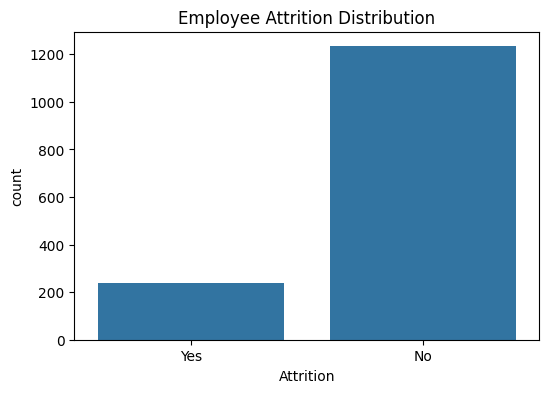


===== Logistic Regression =====
Accuracy: 0.8741496598639455
F1 Score: 0.4931506849315068

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



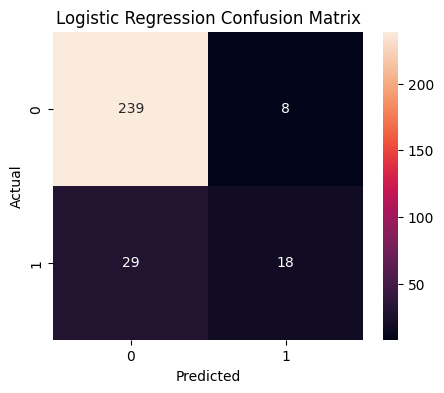


===== Decision Tree =====
Accuracy: 0.8435374149659864
F1 Score: 0.28125

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.53      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.70      0.58      0.60       294
weighted avg       0.81      0.84      0.81       294



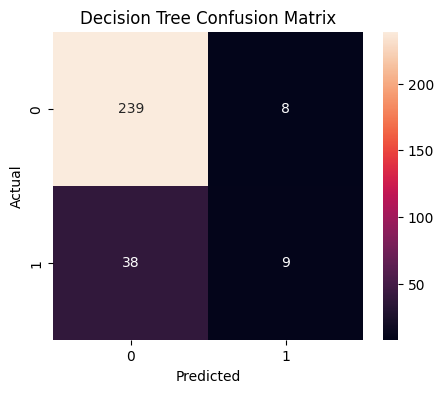


===== Random Forest =====
Accuracy: 0.8299319727891157
F1 Score: 0.16666666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



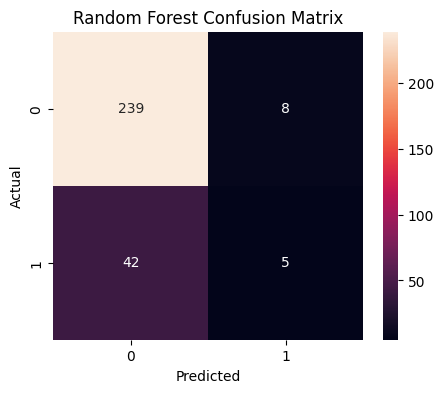


===== Model Comparison =====
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.874150  0.493151
1        Decision Tree  0.843537  0.281250
2        Random Forest  0.829932  0.166667


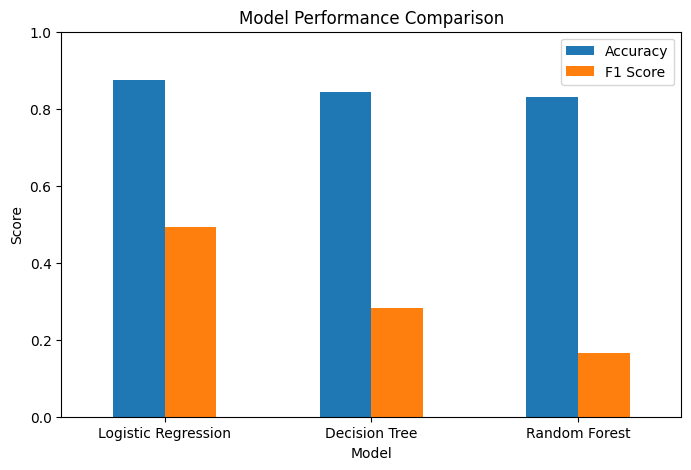


===== Top 10 Important Features =====
              Feature  Importance
17      MonthlyIncome    0.071365
0                 Age    0.063924
27  TotalWorkingYears    0.060061
2           DailyRate    0.051142
11         HourlyRate    0.050359
18        MonthlyRate    0.047954
8      EmployeeNumber    0.043478
4    DistanceFromHome    0.043328
21           OverTime    0.042244
30     YearsAtCompany    0.039755


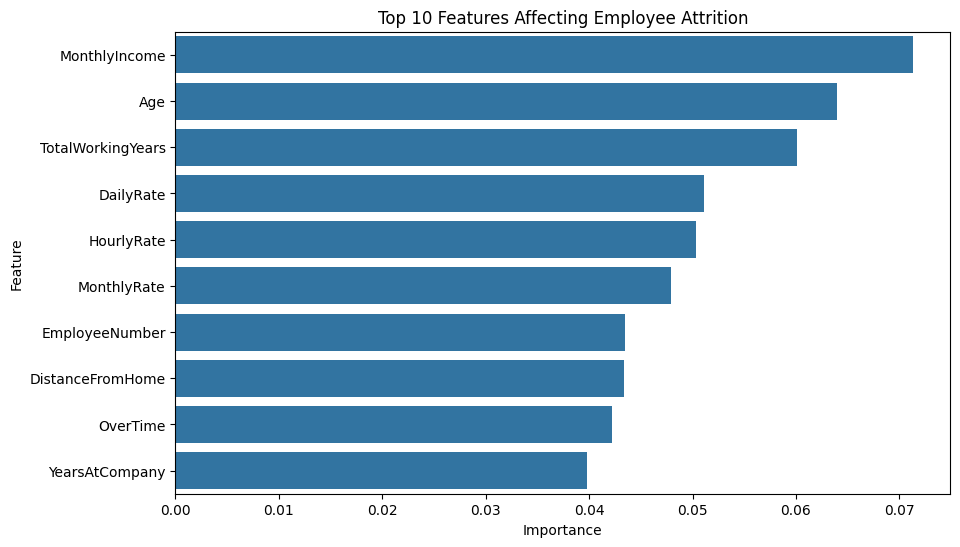

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load the dataset from the Kaggle path
dataset_dir = '/kaggle/input/ibm-hr-analytics-attrition-dataset'
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(dataset_dir, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset successfully from {csv_path}")
else:
    raise FileNotFoundError("No CSV file found in the dataset directory.")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


# Attrition distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.show()


# Convert categorical data into numbers
label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])


# Separate input and output
X = df.drop("Attrition", axis=1)
y = df["Attrition"]


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Scaling for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================
# Logistic Regression
# ==============================

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_prediction = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, logistic_prediction)
logistic_f1 = f1_score(y_test, logistic_prediction)

print("\n===== Logistic Regression =====")
print("Accuracy:", logistic_accuracy)
print("F1 Score:", logistic_f1)

print("\nClassification Report:")
print(classification_report(y_test, logistic_prediction))


plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, logistic_prediction),
    annot=True,
    fmt="d"
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# Decision Tree
# ==============================

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

tree_prediction = decision_tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_prediction)
tree_f1 = f1_score(y_test, tree_prediction)

print("\n===== Decision Tree =====")
print("Accuracy:", tree_accuracy)
print("F1 Score:", tree_f1)

print("\nClassification Report:")
print(classification_report(y_test, tree_prediction))


plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, tree_prediction),
    annot=True,
    fmt="d"
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# Random Forest
# ==============================

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

forest_prediction = random_forest.predict(X_test)

forest_accuracy = accuracy_score(y_test, forest_prediction)
forest_f1 = f1_score(y_test, forest_prediction)

print("\n===== Random Forest =====")
print("Accuracy:", forest_accuracy)
print("F1 Score:", forest_f1)

print("\nClassification Report:")
print(classification_report(y_test, forest_prediction))


plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, forest_prediction),
    annot=True,
    fmt="d"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==============================
# Model Comparison
# ==============================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

print("\n===== Model Comparison =====")
print(results)


# Comparison graph
results.plot(
    x="Model",
    y=["Accuracy", "F1 Score"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


# ==============================
# Feature Importance
# ==============================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n===== Top 10 Important Features =====")
print(feature_importance.head(10))


plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Features Affecting Employee Attrition")
plt.show()